In [2]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE')

from google.colab import drive
drive.mount('/content/drive')

import os
ROOT = '/content/drive/MyDrive/grpo_part2'
os.makedirs(f'{ROOT}/checkpoints', exist_ok=True)
print('ROOT:', ROOT, 'exists:', os.path.exists(ROOT))

# Check what's already there
if os.path.exists(f'{ROOT}/checkpoints'):
    for d in sorted(os.listdir(f'{ROOT}/checkpoints')):
        p = f'{ROOT}/checkpoints/{d}'
        if os.path.isdir(p):
            print(' ', d, '→ contents:', os.listdir(p) if len(os.listdir(p)) < 10 else f'{len(os.listdir(p))} files')

# Check for previous eval JSONs
for f in os.listdir(ROOT):
    if f.endswith('.json'):
        print(' eval file:', f)

GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT: /content/drive/MyDrive/grpo_part2 exists: True
  a03_s42 → contents: ['README.md', 'checkpoint-50', 'final']
  a03_s7 → contents: ['README.md', 'checkpoint-50', 'final']
  a05_s7 → contents: ['README.md', 'checkpoint-50', 'final']
  a07_s42 → contents: ['README.md', 'checkpoint-50', 'final']
  a07_s7 → contents: ['README.md', 'checkpoint-50', 'final']
  a10_s7 → contents: ['README.md', 'checkpoint-50', 'final']
  baseline_a10 → contents: ['checkpoint-25', 'checkpoint-50', 'README.md', 'final']
  hybrid_a05 → contents: ['checkpoint-25', 'checkpoint-50', 'final', 'README.md']
 eval file: eval_baseline_a10.json
 eval file: eval_hybrid_a05.json
 eval file: eval_a10_s7.json


In [3]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE')

from google.colab import drive
drive.mount('/content/drive')

import os
ROOT = '/content/drive/MyDrive/grpo_part2'

GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install -q --upgrade transformers trl peft accelerate datasets torchao bitsandbytes

In [5]:
import trl, transformers, peft
print("TRL:", trl.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)

from trl import GRPOConfig, GRPOTrainer
print("Imports OK")

TRL: 1.9.0
Transformers: 5.14.1
PEFT: 0.19.1
Imports OK


In [6]:
import os, re, torch
os.environ["TOKENIZERS_PARALLELISM"] = "false"

ROOT = '/content/drive/MyDrive/grpo_part2'
os.makedirs(f'{ROOT}/checkpoints', exist_ok=True)

# ---- Model + LoRA ----
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tok = AutoTokenizer.from_pretrained(model_id)
tok.pad_token = tok.eos_token

model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map="auto")

lora = LoraConfig(r=16, lora_alpha=32,
                  target_modules=["q_proj","v_proj","k_proj","o_proj"],
                  lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
model = get_peft_model(model, lora)
model.print_trainable_parameters()
print(f"VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079
VRAM: 2.22 GB


In [7]:
# ---- Reward functions ----
def extract_answer(text):
    m = re.search(r"####\s*(-?[\d,]+\.?\d*)", text)
    if m:
        try: return float(m.group(1).replace(",", ""))
        except ValueError: pass
    nums = re.findall(r"-?\d+\.?\d*", text)
    if nums:
        try: return float(nums[-1])
        except ValueError: return None
    return None

def reward_outcome(completion, ground_truth):
    pred = extract_answer(completion)
    truth = extract_answer(ground_truth)
    if pred is None or truth is None: return 0.0
    return 1.0 if abs(pred - truth) < 1e-3 else 0.0

def arithmetic_validity(step_text):
    pat = r"(-?\d+\.?\d*)\s*([\+\-\*\/x×÷])\s*(-?\d+\.?\d*)\s*=\s*(-?\d+\.?\d*)"
    matches = re.findall(pat, step_text)
    if not matches: return None
    correct, total = 0, 0
    for a, op, b, c in matches:
        try:
            a, b, c = float(a), float(b), float(c)
        except ValueError:
            continue
        op_n = {"x": "*", "×": "*", "÷": "/"}.get(op, op)
        try:
            if op_n == "+":
                exp = a + b
            elif op_n == "-":
                exp = a - b
            elif op_n == "*":
                exp = a * b
            elif op_n == "/":
                if b == 0: continue
                exp = a / b
            else: continue
        except Exception:
            continue
        total += 1
        if abs(exp - c) < 1e-3: correct += 1
    return correct / total if total > 0 else None

def reward_process(completion):
    steps = [s.strip() for s in completion.split("\n") if s.strip()]
    if not steps: return 0.0
    scores = [arithmetic_validity(s) for s in steps]
    scores = [s if s is not None else 0.5 for s in scores]
    return sum(scores) / len(scores)

def reward_total(completion, ground_truth, alpha=0.5):
    return alpha * reward_outcome(completion, ground_truth) + (1 - alpha) * reward_process(completion)

print("Rewards defined:", callable(reward_total))

# ---- Dataset ----
from datasets import load_dataset
gsm8k = load_dataset("openai/gsm8k", "main")
SYSTEM_PROMPT = "You are a maths tutor. Solve the problem step by step. Show each calculation. End with '#### <number>' giving the final numeric answer."

def format_prompt(example):
    chat = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["question"]}]
    return {"prompt": tok.apply_chat_template(chat, tokenize=False, add_generation_prompt=True),
            "answer": example["answer"]}

train_subset = gsm8k["train"].shuffle(seed=42).select(range(200)).map(format_prompt)
print("Train subset:", len(train_subset), "columns:", train_subset.column_names)

Rewards defined: True
Train subset: 200 columns: ['question', 'answer', 'prompt']


In [8]:
from datasets import load_dataset
gsm8k = load_dataset("openai/gsm8k", "main")
print("Train:", len(gsm8k["train"]), "Test:", len(gsm8k["test"]))

Train: 7473 Test: 1319


In [9]:
SYSTEM_PROMPT = "You are a maths tutor. Solve the problem step by step. Show each calculation. End with '#### <number>' giving the final numeric answer."

def format_prompt(example):
    chat = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["question"]}]
    return {"prompt": tok.apply_chat_template(chat, tokenize=False, add_generation_prompt=True),
            "answer": example["answer"]}

train_subset = gsm8k["train"].shuffle(seed=42).select(range(200)).map(format_prompt)
print("Train subset:", len(train_subset), "columns:", train_subset.column_names)


Train subset: 200 columns: ['question', 'answer', 'prompt']


In [10]:
import gc, time
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
from trl import GRPOConfig, GRPOTrainer

def run_grpo(alpha, seed, max_steps=50):
    """One GRPO training run with given alpha and seed. Saves adapter to Drive."""
    run_name = f"a{int(alpha*10):02d}_s{seed}"
    out_dir = f"{ROOT}/checkpoints/{run_name}"
    final_path = f"{out_dir}/final"

    # Skip if already trained
    if os.path.exists(final_path) and os.listdir(final_path):
        print(f"[SKIP] {run_name} already exists")
        return final_path

    print(f"\n{'='*60}\n=== RUN {run_name}  (alpha={alpha}, seed={seed}) ===\n{'='*60}")

    # Fresh model + LoRA every run
    global model
    try:
        del model
    except NameError:
        pass
    gc.collect()
    torch.cuda.empty_cache()

    torch.manual_seed(seed)

    m = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map="auto")
    lora = LoraConfig(r=16, lora_alpha=32,
                      target_modules=["q_proj","v_proj","k_proj","o_proj"],
                      lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
    m = get_peft_model(m, lora)

    # Reward function closes over alpha
    def reward_fn(prompts, completions, **kwargs):
        truths = kwargs["answer"]
        return [float(reward_total(c, t, alpha=alpha)) for c, t in zip(completions, truths)]

    config = GRPOConfig(
        output_dir=out_dir,
        learning_rate=1e-5,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=2,
        num_generations=4,
        max_completion_length=200,
        max_steps=max_steps,
        save_steps=max_steps,   # only save at end (saves Drive space)
        logging_steps=5,
        seed=seed,
        report_to="none",
        fp16=True,
        remove_unused_columns=False,
        temperature=0.9,
        beta=0.04,
    )

    trainer = GRPOTrainer(
        model=m, args=config, reward_funcs=reward_fn,
        train_dataset=train_subset, processing_class=tok,
    )

    t0 = time.time()
    trainer.train()
    print(f"  elapsed: {(time.time()-t0)/60:.1f} min")

    trainer.save_model(final_path)
    print(f"  saved to {final_path}")

    del trainer, m
    gc.collect()
    torch.cuda.empty_cache()
    return final_path

print("run_grpo() ready.")

run_grpo() ready.


In [11]:
# Full grid — recovered from previous session (a10_s42, a05_s42 already saved as
# baseline_a10 and hybrid_a05); we skip them and rename here.
# For clarity we run all 6 remaining conditions.

runs_to_do = [
    (1.0, 7),   # baseline seed 2
    (0.7, 42),
    (0.7, 7),
    (0.5, 7),   # hybrid seed 2
    (0.3, 42),
    (0.3, 7),
]

paths = {}
for alpha, seed in runs_to_do:
    p = run_grpo(alpha, seed)
    paths[(alpha, seed)] = p

# Also map the recovered runs into the same naming scheme
# Old paths: baseline_a10/final, hybrid_a05/final
paths[(1.0, 42)] = f"{ROOT}/checkpoints/baseline_a10/final"
paths[(0.5, 42)] = f"{ROOT}/checkpoints/hybrid_a05/final"

print("\n=== ALL RUNS COMPLETE ===")
for (a, s), p in sorted(paths.items()):
    exists = os.path.exists(p)
    print(f"  a={a:.1f} s={s:02d}: {p} (exists: {exists})")

[SKIP] a10_s7 already exists
[SKIP] a07_s42 already exists
[SKIP] a07_s7 already exists
[SKIP] a05_s7 already exists
[SKIP] a03_s42 already exists
[SKIP] a03_s7 already exists

=== ALL RUNS COMPLETE ===
  a=0.3 s=07: /content/drive/MyDrive/grpo_part2/checkpoints/a03_s7/final (exists: True)
  a=0.3 s=42: /content/drive/MyDrive/grpo_part2/checkpoints/a03_s42/final (exists: True)
  a=0.5 s=07: /content/drive/MyDrive/grpo_part2/checkpoints/a05_s7/final (exists: True)
  a=0.5 s=42: /content/drive/MyDrive/grpo_part2/checkpoints/hybrid_a05/final (exists: True)
  a=0.7 s=07: /content/drive/MyDrive/grpo_part2/checkpoints/a07_s7/final (exists: True)
  a=0.7 s=42: /content/drive/MyDrive/grpo_part2/checkpoints/a07_s42/final (exists: True)
  a=1.0 s=07: /content/drive/MyDrive/grpo_part2/checkpoints/a10_s7/final (exists: True)
  a=1.0 s=42: /content/drive/MyDrive/grpo_part2/checkpoints/baseline_a10/final (exists: True)


In [12]:
import torch, gc, json
from transformers import AutoModelForCausalLM
from peft import PeftModel
from datasets import load_dataset

# Free training memory
try:
    del trainer
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

# Fixed test subset — same problems, same order, all runs
TEST_N = 80
gsm8k = load_dataset("openai/gsm8k", "main")
SYSTEM_PROMPT = "You are a maths tutor. Solve the problem step by step. Show each calculation. End with '#### <number>' giving the final numeric answer."
test_subset = gsm8k["test"].shuffle(seed=123).select(range(TEST_N))
print(f"Test set: {TEST_N} problems")

@torch.no_grad()
def generate_one(m, question, max_new_tokens=200):
    chat = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    prompt = tok.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
    inputs = tok(prompt, return_tensors="pt", truncation=True, max_length=512).to(m.device)
    out = m.generate(
        **inputs, max_new_tokens=max_new_tokens,
        do_sample=True, temperature=0.7, top_p=0.9,
        pad_token_id=tok.eos_token_id,
    )
    return tok.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

def evaluate_adapter(adapter_path, label):
    """Load adapter, generate, score."""
    print(f"\n--- {label} ---")
    base = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map="auto")
    m = PeftModel.from_pretrained(base, adapter_path)
    m.eval()

    results = []
    for i, ex in enumerate(test_subset):
        completion = generate_one(m, ex["question"])
        results.append({
            "idx": i,
            "r_outcome": reward_outcome(completion, ex["answer"]),
            "r_process": reward_process(completion),
            "chain_length": len([s for s in completion.split("\n") if s.strip()]),
        })
        if (i+1) % 20 == 0:
            print(f"  {i+1}/{TEST_N}")

    del m, base
    gc.collect()
    torch.cuda.empty_cache()

    out_path = f"{ROOT}/eval_{label}.json"
    with open(out_path, "w") as f:
        json.dump(results, f)
    print(f"  saved → {out_path}")
    return results

# All 8 conditions
conditions = [
    (1.0, 42, "baseline_a10"),      # recovered from previous session
    (1.0, 7,  "a10_s7"),
    (0.7, 42, "a07_s42"),
    (0.7, 7,  "a07_s7"),
    (0.5, 42, "hybrid_a05"),         # recovered from previous session
    (0.5, 7,  "a05_s7"),
    (0.3, 42, "a03_s42"),
    (0.3, 7,  "a03_s7"),
]

all_results = {}
for alpha, seed, run_name in conditions:
    path = f"{ROOT}/checkpoints/{run_name}/final"
    all_results[(alpha, seed)] = evaluate_adapter(path, run_name)

print("\n=== EVAL COMPLETE ===")

# Summary
import numpy as np
def summarise(results, label):
    acc = np.mean([r["r_outcome"] for r in results])
    proc = np.mean([r["r_process"] for r in results])
    cl = np.mean([r["chain_length"] for r in results])
    return acc, proc, cl

print(f"\n{'condition':<20} {'acc':>6} {'proc':>6} {'chain':>7}")
print("-" * 42)
for (alpha, seed), results in all_results.items():
    acc, proc, cl = summarise(results, f"a{alpha}_s{seed}")
    print(f"α={alpha:.1f} seed={seed:<4}    {acc:>6.3f} {proc:>6.3f} {cl:>7.1f}")

Test set: 80 problems

--- baseline_a10 ---


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

  20/80


[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

...

  40/80


[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

  60/80


[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

  80/80
  saved → /content/drive/MyDrive/grpo_part2/eval_a03_s7.json

=== EVAL COMPLETE ===

condition               acc   proc   chain
------------------------------------------
α=1.0 seed=42       0.037  0.503     7.2
α=1.0 seed=7        0.037  0.501     5.8
α=0.7 seed=42       0.050  0.497     6.3
α=0.7 seed=7        0.037  0.506     6.2
α=0.5 seed=42       0.025  0.483     6.5
α=0.5 seed=7        0.025  0.494     7.1
α=0.3 seed=42       0.013  0.502     6.1
α=0.3 seed=7        0.000  0.504     6.6


=== Paired bootstrap 95% CI vs baseline (α=1.0) ===

α=0.3:
  Δaccuracy       = -0.031   CI [-0.062, +0.000]
  Δstep_validity  = +0.001   CI [-0.026, +0.028]
  Δchain_length   = -0.12    CI [-0.99, +0.71]

α=0.5:
  Δaccuracy       = -0.013   CI [-0.050, +0.025]
  Δstep_validity  = -0.014   CI [-0.034, +0.006]
  Δchain_length   = +0.35    CI [-0.49, +1.19]

α=0.7:
  Δaccuracy       = +0.006   CI [-0.031, +0.044]
  Δstep_validity  = -0.001   CI [-0.021, +0.019]
  Δchain_length   = -0.23    CI [-1.10, +0.61]



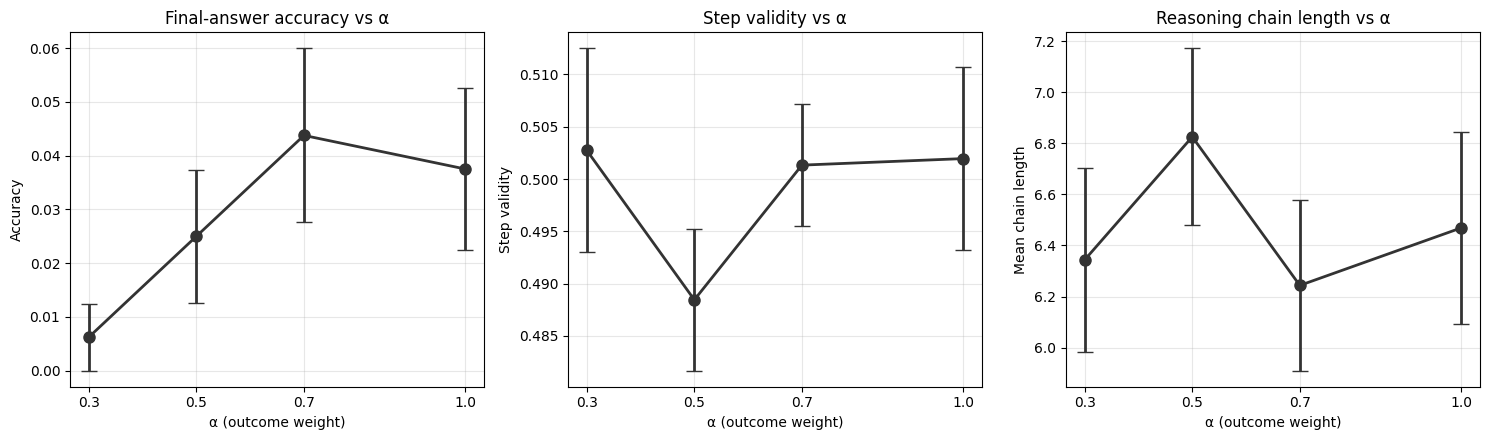


Saved: /content/drive/MyDrive/grpo_part2/results_plot.png


In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt

conditions = [
    (1.0, 42, "baseline_a10"), (1.0, 7, "a10_s7"),
    (0.7, 42, "a07_s42"),      (0.7, 7, "a07_s7"),
    (0.5, 42, "hybrid_a05"),   (0.5, 7, "a05_s7"),
    (0.3, 42, "a03_s42"),      (0.3, 7, "a03_s7"),
]

data = {}
for alpha, seed, name in conditions:
    with open(f"{ROOT}/eval_{name}.json") as f:
        data[(alpha, seed)] = json.load(f)

alphas = [0.3, 0.5, 0.7, 1.0]
def get_metric(alpha, key):
    values = []
    for s in [42, 7]:
        values.extend([r[key] for r in data[(alpha, s)]])
    return np.array(values)

def paired_bootstrap(a, b, n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(a), len(a))
        diffs.append(a[idx].mean() - b[idx].mean())
    diffs = np.array(diffs)
    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])

print("=== Paired bootstrap 95% CI vs baseline (α=1.0) ===\n")
baseline_acc  = get_metric(1.0, "r_outcome")
baseline_proc = get_metric(1.0, "r_process")
baseline_cl   = get_metric(1.0, "chain_length")

for a in [0.3, 0.5, 0.7]:
    acc  = get_metric(a, "r_outcome")
    proc = get_metric(a, "r_process")
    cl   = get_metric(a, "chain_length")
    d_acc, ci_acc = paired_bootstrap(acc, baseline_acc)
    d_proc, ci_proc = paired_bootstrap(proc, baseline_proc)
    d_cl, ci_cl = paired_bootstrap(cl, baseline_cl)
    print(f"α={a}:")
    print(f"  Δaccuracy       = {d_acc:+.3f}   CI [{ci_acc[0]:+.3f}, {ci_acc[1]:+.3f}]")
    print(f"  Δstep_validity  = {d_proc:+.3f}   CI [{ci_proc[0]:+.3f}, {ci_proc[1]:+.3f}]")
    print(f"  Δchain_length   = {d_cl:+.2f}    CI [{ci_cl[0]:+.2f}, {ci_cl[1]:+.2f}]")
    print()

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, key, ylabel, title in zip(
    axes,
    ["r_outcome", "r_process", "chain_length"],
    ["Accuracy", "Step validity", "Mean chain length"],
    ["Final-answer accuracy vs α", "Step validity vs α", "Reasoning chain length vs α"],
):
    means = [get_metric(a, key).mean() for a in alphas]
    sems  = [get_metric(a, key).std()/np.sqrt(len(get_metric(a, key))) for a in alphas]
    ax.errorbar(alphas, means, yerr=sems, fmt='o-', capsize=6, color='#333', linewidth=2, markersize=8)
    ax.set_xlabel("α (outcome weight)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.set_xticks(alphas)

plt.tight_layout()
plt.savefig(f"{ROOT}/results_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {ROOT}/results_plot.png")

In [16]:
import json
import numpy as np

conditions = [
    (1.0, 42, "baseline_a10"), (1.0, 7, "a10_s7"),
    (0.7, 42, "a07_s42"),      (0.7, 7, "a07_s7"),
    (0.5, 42, "hybrid_a05"),   (0.5, 7, "a05_s7"),
    (0.3, 42, "a03_s42"),      (0.3, 7, "a03_s7"),
]

data = {}
for alpha, seed, name in conditions:
    with open(f"{ROOT}/eval_{name}.json") as f:
        data[(alpha, seed)] = json.load(f)

# For each (problem_idx, seed), pair the a=0.X vs a=1.0 values
def paired_values(alpha, key):
    """Return arrays a_values, b_values where index i in both refers to same (problem, seed)."""
    a_vals, b_vals = [], []
    for s in [42, 7]:
        A = data[(alpha, s)]
        B = data[(1.0, s)]
        for i in range(len(A)):
            a_vals.append(A[i][key])
            b_vals.append(B[i][key])
    return np.array(a_vals), np.array(b_vals)

def paired_bootstrap(a, b, n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    diffs = a - b  # per-problem difference (paired)
    mean_diff = diffs.mean()
    boot_means = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(diffs), len(diffs))
        boot_means.append(diffs[idx].mean())
    return mean_diff, np.percentile(boot_means, [2.5, 97.5])

print("=== Paired bootstrap 95% CI vs baseline (α=1.0), per-problem paired ===\n")
for a in [0.3, 0.5, 0.7]:
    print(f"α={a}:")
    for key, label in [("r_outcome", "Δaccuracy      "),
                        ("r_process", "Δstep_validity "),
                        ("chain_length", "Δchain_length  ")]:
        a_vals, b_vals = paired_values(a, key)
        mean_d, ci = paired_bootstrap(a_vals, b_vals)
        print(f"  {label} = {mean_d:+.3f}   CI [{ci[0]:+.3f}, {ci[1]:+.3f}]")
    print()

# Also print raw means per alpha for the report table
print("=== Raw means per α ===\n")
print(f"{'α':>4}  {'accuracy':>10}  {'step_val':>10}  {'chain_len':>10}")
for a in [1.0, 0.7, 0.5, 0.3]:
    all_acc, all_proc, all_cl = [], [], []
    for s in [42, 7]:
        for r in data[(a, s)]:
            all_acc.append(r["r_outcome"])
            all_proc.append(r["r_process"])
            all_cl.append(r["chain_length"])
    print(f"{a:>4.1f}  {np.mean(all_acc):>10.3f}  {np.mean(all_proc):>10.3f}  {np.mean(all_cl):>10.2f}")

=== Paired bootstrap 95% CI vs baseline (α=1.0), per-problem paired ===

α=0.3:
  Δaccuracy       = -0.031   CI [-0.062, +0.000]
  Δstep_validity  = +0.001   CI [-0.026, +0.028]
  Δchain_length   = -0.125   CI [-0.994, +0.713]

α=0.5:
  Δaccuracy       = -0.013   CI [-0.050, +0.025]
  Δstep_validity  = -0.014   CI [-0.034, +0.006]
  Δchain_length   = +0.356   CI [-0.487, +1.188]

α=0.7:
  Δaccuracy       = +0.006   CI [-0.031, +0.044]
  Δstep_validity  = -0.001   CI [-0.021, +0.019]
  Δchain_length   = -0.225   CI [-1.100, +0.613]

=== Raw means per α ===

   α    accuracy    step_val   chain_len
 1.0       0.037       0.502        6.47
 0.7       0.044       0.501        6.24
 0.5       0.025       0.488        6.83
 0.3       0.006       0.503        6.34
